# 11 — Color, Typography & Brand
**Goal:** Use color with intent (categorical, sequential, diverging, brand),
honor accessibility, and pick typography that earns its space.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, to_hex

print('matplotlib', mpl.__version__)

matplotlib 3.11.0


## 1. The three semantics of color

Color must answer one of three questions:

| Semantics | Question it answers | Palette type |
|---|---|---|
| **Categorical** | "Which group?" | Distinct hues (e.g. `tab10`) |
| **Sequential** | "How much more / less?" | Single-hue gradient (e.g. `YlGnBu`) |
| **Diverging** | "Above or below a center?" | Two-hue gradient with neutral center (e.g. `RdBu`) |

Mismatches cause real damage: a rainbow on quantitative data implies
boundaries that do not exist; a single hue on a diverging question loses the
sign.

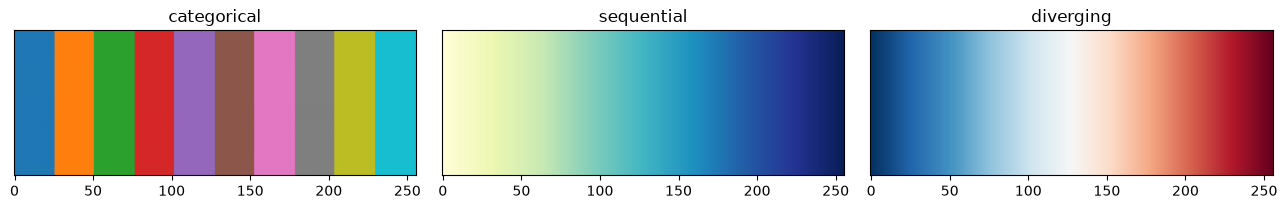

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 2.2))
for ax, cmap, name in zip(axes, ['tab10', 'YlGnBu', 'RdBu_r'],
                          ['categorical', 'sequential', 'diverging']):
    grad = np.linspace(0, 1, 256).reshape(1, -1)
    ax.imshow(grad, aspect='auto', cmap=cmap)
    ax.set_title(name); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 2. Building a custom palette

For brand charts, hand-pick the colors and register them with matplotlib.

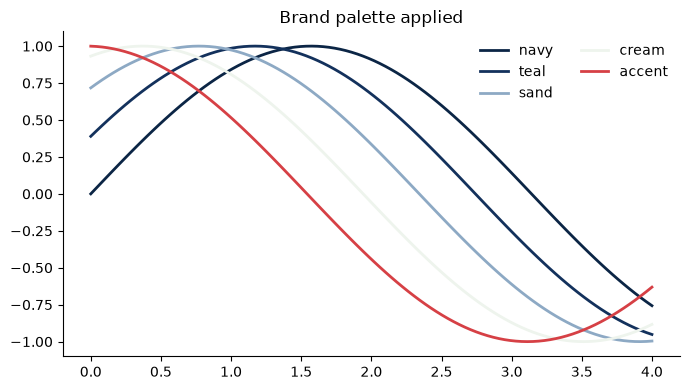

In [3]:
BRAND = {
    'navy'    : '#0B2545',
    'teal'    : '#13315C',
    'sand'    : '#8DA9C4',
    'cream'   : '#EEF4ED',
    'accent'  : '#D64045',
}

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=list(BRAND.values()))
fig, ax = plt.subplots(figsize=(7, 4))
x = np.linspace(0, 4, 100)
for i, k in enumerate(BRAND):
    ax.plot(x, np.sin(x + i*0.4), color=BRAND[k], lw=2, label=k)
ax.set_title('Brand palette applied')
ax.legend(frameon=False, ncol=2)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 3. Accessibility — color-blind safe palettes

~8% of men and ~0.5% of women have some form of color-vision deficiency. The
two most common are deuteranopia (red-green) and protanopia (red-green). The
fastest fix:

- Use `colorblind` or `tableau-colorblind10` palettes.
- Never rely on *color alone* — pair with shape, line style, or direct label.
- Check with a simulator.

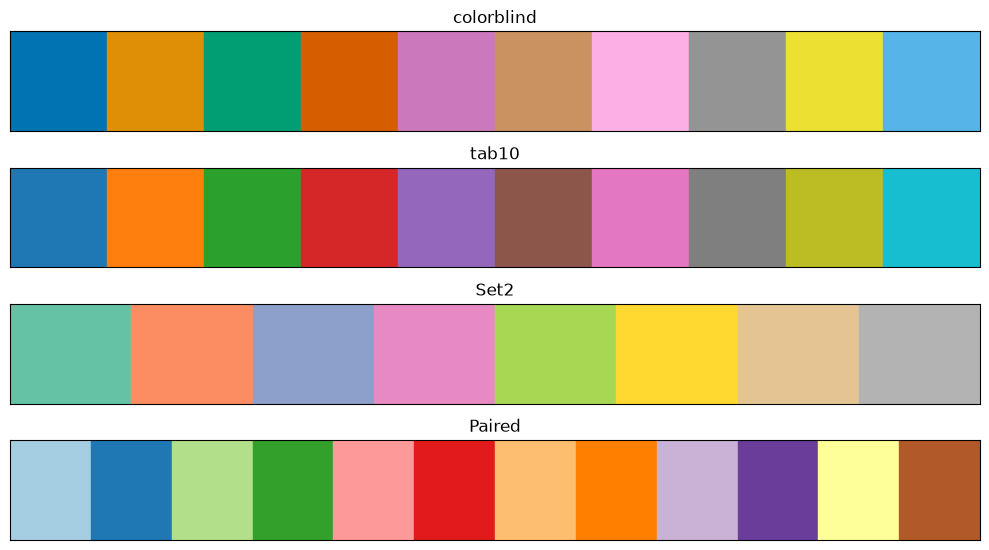

In [4]:
import seaborn as sns
palettes = ['colorblind', 'tab10', 'Set2', 'Paired']
fig, axes = plt.subplots(len(palettes), 1, figsize=(10, 1.4 * len(palettes)))
for ax, p in zip(axes, palettes):
    palette = sns.color_palette(p)
    n = len(palette)
    for i, color in enumerate(palette):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
    ax.set_xlim(0, n); ax.set_ylim(0, 1); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(p)
plt.tight_layout(); plt.show()

## 4. The "McKinsey / FT / Bloomberg" look

Three recognizable publication styles:

- **McKinsey** — muted primary, lots of negative space, a single accent color,
  bold sans-serif titles in the top-left, very few gridlines.
- **FT** — salmon background, dark navy text, serif title, a small set of
  accent colors.
- **Bloomberg** — black background, neon accent, condensed sans, dense data.

The common thread: **consistency**, **restraint**, **typography over chrome**.

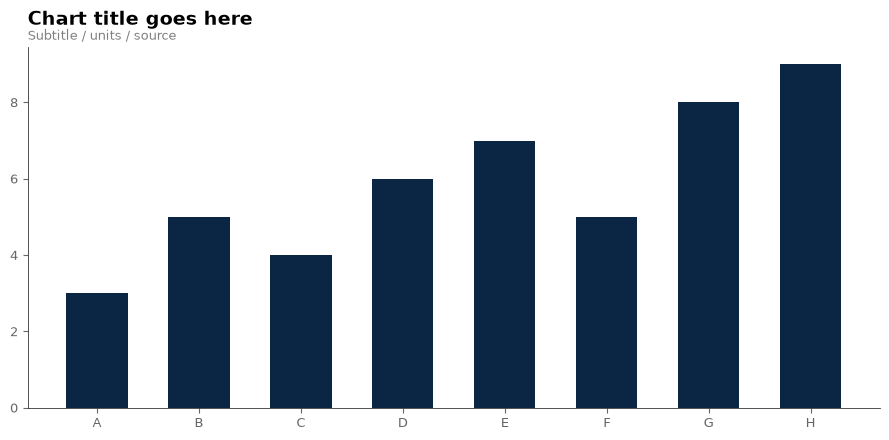

In [5]:
def mckinsey_style():
    return {
        'figure.facecolor': 'white',
        'axes.facecolor'  : 'white',
        'axes.edgecolor'  : '#333333',
        'axes.linewidth'  : 0.6,
        'axes.spines.top' : False,
        'axes.spines.right': False,
        'axes.grid'       : False,
        'axes.titlesize'  : 14,
        'axes.titleweight': 'bold',
        'axes.titlepad'   : 16,
        'axes.labelsize'  : 10,
        'xtick.labelsize' : 9,
        'ytick.labelsize' : 9,
        'xtick.color'     : '#666666',
        'ytick.color'     : '#666666',
        'font.family'     : 'DejaVu Sans',
        'font.size'       : 10,
    }

with plt.style.context({}):
    mpl.rcParams.update(mckinsey_style())
    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = np.arange(8); labels = list('ABCDEFGH')
    ax.bar(x, [3,5,4,6,7,5,8,9], color='#0B2545', width=0.6)
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_title('Chart title goes here', loc='left', weight='bold')
    ax.text(0, 1.02, 'Subtitle / units / source', transform=ax.transAxes,
            color='gray', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout(); plt.show()

## 5. Typography — font choice and hierarchy

Three things decide readability: **font**, **size**, and **weight**.

Default matplotlib font is `DejaVu Sans`. Good alternates available out of
the box: `serif`, `monospace`.

Hierarchy (typical):

- Title: 13–16, bold
- Subtitle: 9–10, regular, gray
- Axis label: 10, regular
- Tick labels: 8–9, regular, gray
- Annotation: 9–10, bold if it carries the finding

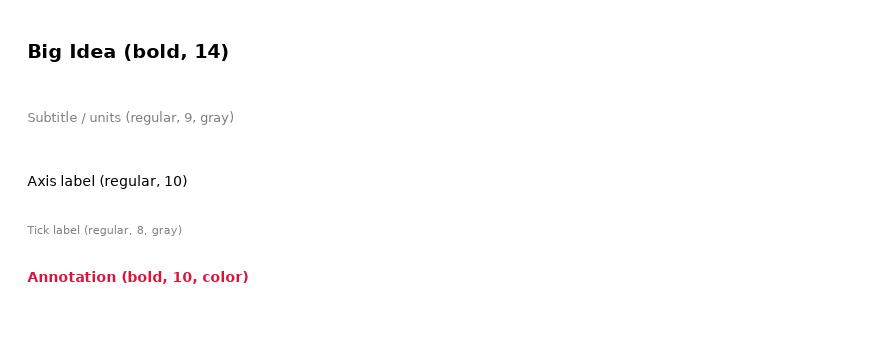

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.axis('off')
ax.text(0.02, 0.85, 'Big Idea (bold, 14)', fontsize=14, weight='bold')
ax.text(0.02, 0.65, 'Subtitle / units (regular, 9, gray)', fontsize=9, color='gray')
ax.text(0.02, 0.45, 'Axis label (regular, 10)', fontsize=10)
ax.text(0.02, 0.30, 'Tick label (regular, 8, gray)', fontsize=8, color='gray')
ax.text(0.02, 0.15, 'Annotation (bold, 10, color)', fontsize=10, weight='bold', color='crimson')
plt.tight_layout(); plt.show()

## 6. Designing a brand palette

A practical recipe:

1. One **primary** (your brand color).
2. Two **neutrals** (near-black, near-white).
3. One **accent** (used sparingly for the highlight).
4. Up to three **categorical** colors for multi-series charts.
5. One **sequential** colormap (for heatmaps, single-hue).
6. One **diverging** colormap (for deviation from a target).

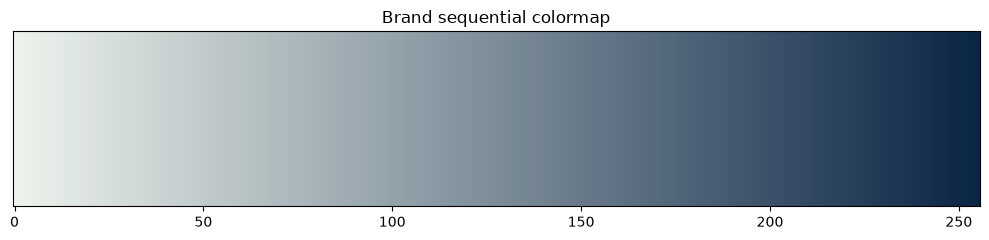

In [7]:
system = {
    'primary'   : '#0B2545',
    'neutral_d' : '#2F2F2F',
    'neutral_l' : '#F2F2F2',
    'accent'    : '#D64045',
    'cat1'      : '#0B2545',
    'cat2'      : '#8DA9C4',
    'cat3'      : '#D64045',
    'seq'       : LinearSegmentedColormap.from_list('brand_seq', ['#EEF4ED', '#0B2545']),
    'div'       : LinearSegmentedColormap.from_list('brand_div', ['#D64045', '#EEF4ED', '#0B2545']),
}

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.imshow(np.linspace(0, 1, 256).reshape(1, -1), cmap=system['seq'], aspect='auto')
ax.set_yticks([]); ax.set_title('Brand sequential colormap')
plt.tight_layout(); plt.show()

## 7. The "less is more" check

Before shipping a chart, run a four-point audit:

1. Could I remove any *color*? Replace with gray.
2. Could I remove any *line*? Replace with whitespace.
3. Could I remove any *word*? Shorten or move to subtitle.
4. Could I remove any *chart*? Multiple insights → one chart.

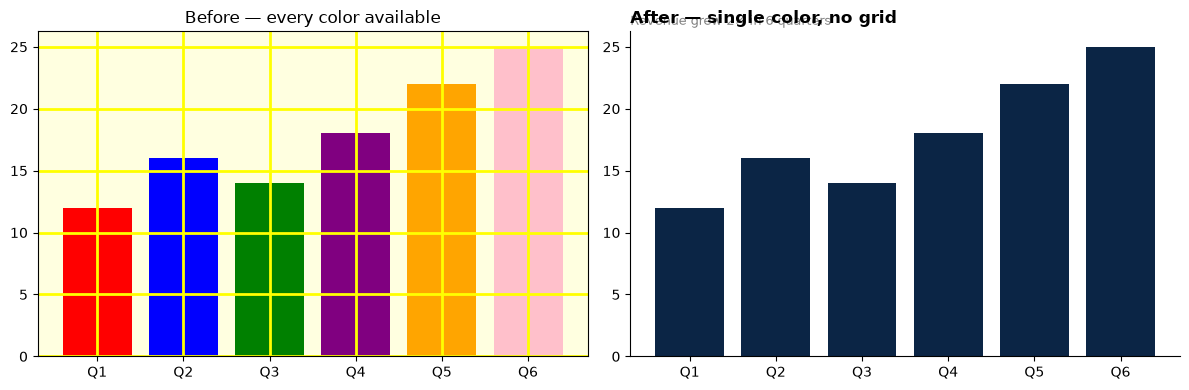

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(6); vals = [12, 16, 14, 18, 22, 25]
labels = ['Q1','Q2','Q3','Q4','Q5','Q6']

axes[0].bar(x, vals, color=['red','blue','green','purple','orange','pink'])
axes[0].grid(True, color='yellow', linewidth=2)
axes[0].set_facecolor('lightyellow')
axes[0].set_title('Before — every color available')

axes[1].bar(x, vals, color='#0B2545')
axes[1].set_title('After — single color, no grid', loc='left', weight='bold')
axes[1].text(0, 1.02, 'Revenue grew 2× in 6 quarters', transform=axes[1].transAxes,
             color='gray', fontsize=9)
axes[1].spines[['top','right']].set_visible(False)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
plt.tight_layout(); plt.show()

## Summary

| Topic | Rule |
|---|---|
| Color semantics | Categorical / sequential / diverging — match the question |
| Brand palette | 1 primary, 2 neutrals, 1 accent, 3 categorical max |
| Accessibility | `colorblind` palette; never color alone |
| Typography | Title bold, subtitle gray, labels regular |
| Less is more | Run the four-point audit before shipping |

**Next:** `12_specialty_charts.ipynb` — waterfall, sankey, treemap, funnel.